# Visa Application Risk Scoring: Building Production-Grade Immigration Decision Support ML

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Immigration risk assessment and visa decision support for border agencies and government departments

---

This notebook builds a production-oriented ML system for visa application risk scoring — the kind of decision-support tooling that sits behind modern immigration processing pipelines. While the dataset uses US visa data, we frame the entire analysis around Australian immigration contexts (Department of Home Affairs, ABF, Migration Review Tribunal).

**Why ML-assisted immigration processing matters:**
- Australia processes ~8.5 million visa applications annually across 100+ visa subclasses
- Home Affairs' visa processing times range from days (ETA) to years (family stream)
- Risk-tiered processing allocates limited case officer capacity to highest-risk applications
- Consistency in decision-making reduces review tribunal overturns and litigation risk

**What makes immigration risk scoring different from typical classification:**
- Decisions must be **explainable** — the Migration Act 1958 requires reasons for refusal
- **Fairness constraints** are paramount — models cannot discriminate on protected attributes
- False negatives (approving a high-risk applicant) have national security implications
- False positives (flagging a legitimate applicant) create processing delays and diplomatic friction
- **Regulatory oversight** from the Commonwealth Ombudsman, AAT/ART, and ministerial intervention

**Notebook structure:**
1. Data Loading & Initial Assessment
2. Exploratory Data Analysis
3. Feature Engineering & Preprocessing
4. Applicant Risk Profile Analysis
5. Model Training & Comparison
6. Threshold Tuning & Cost-Sensitive Analysis
7. Model Interpretability & Fairness
8. Production Deployment Considerations
9. Key Takeaways

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve, brier_score_loss,
    classification_report
)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import lightgbm as lgb

import os
import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Color scheme
COLOR_CERTIFIED = '#2ecc71'
COLOR_DENIED = '#e74c3c'
COLOR_PALETTE = [COLOR_CERTIFIED, COLOR_DENIED]

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 1. Data Loading & Initial Assessment

The EasyVisa dataset contains US work visa (PERM) application data with employer and applicant attributes. While US-based, the feature structure maps directly to Australian skilled migration visa processing (subclass 482, 494, 186, 189):

| US Feature | Australian Equivalent |
|------------|----------------------|
| continent (applicant origin) | Passport country / region |
| education_of_employee | Qualification assessment (AQF level) |
| has_job_experience | Skills assessment outcome |
| prevailing_wage | TSMIT (Temporary Skilled Migration Income Threshold) |
| no_of_employees | Sponsor business size |
| yr_of_estab | Sponsor business establishment year |
| region_of_employment | Nominated occupation location (regional vs metro) |

In [2]:
# --- Data Loading: path discovery + load in ONE cell ---
csv_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv'):
            csv_path = os.path.join(root, f)
            break
    if csv_path:
        break

if csv_path is None:
    raise FileNotFoundError("No CSV found under /kaggle/input")

# Auto-detect separator
with open(csv_path, 'r') as fh:
    first_line = fh.readline()
sep = ';' if first_line.count(';') > first_line.count(',') else ','

df = pd.read_csv(csv_path, sep=sep)
print(f"Loaded: {csv_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Separator detected: '{sep}'")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loaded: /kaggle/input/datasets/moro23/easyvisa-dataset/EasyVisa.csv
Shape: 25,480 rows × 12 columns
Separator detected: ','
Memory usage: 13.0 MB


In [3]:
# Schema overview
print("=" * 60)
print("SCHEMA OVERVIEW")
print("=" * 60)
for col in df.columns:
    dtype = df[col].dtype
    nunique = df[col].nunique()
    null_count = df[col].isnull().sum()
    sample = df[col].dropna().iloc[0] if not df[col].dropna().empty else 'N/A'
    print(f"  {col:<30} {str(dtype):<10} unique={nunique:<8} nulls={null_count:<6} sample={sample}")
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
df.head()

SCHEMA OVERVIEW
  case_id                        object     unique=25480    nulls=0      sample=EZYV01
  continent                      object     unique=6        nulls=0      sample=Asia
  education_of_employee          object     unique=4        nulls=0      sample=High School
  has_job_experience             object     unique=2        nulls=0      sample=N
  requires_job_training          object     unique=2        nulls=0      sample=N
  no_of_employees                int64      unique=7105     nulls=0      sample=14513
  yr_of_estab                    int64      unique=199      nulls=0      sample=2007
  region_of_employment           object     unique=5        nulls=0      sample=West
  prevailing_wage                float64    unique=25454    nulls=0      sample=592.2029
  unit_of_wage                   object     unique=4        nulls=0      sample=Hour
  full_time_position             object     unique=2        nulls=0      sample=Y
  case_status                    object     

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [4]:
# Identify target column — look for case_status or similar
target_col = None
for col in df.columns:
    if 'case_status' in col.lower() or 'status' in col.lower():
        target_col = col
        break
# Fallback: look for binary object columns with Certified/Denied
if target_col is None:
    for col in df.select_dtypes(include=['object']).columns:
        vals = df[col].str.lower().unique()
        if any('certif' in str(v) for v in vals) or any('denied' in str(v) for v in vals):
            target_col = col
            break

print(f"Target column: {target_col}")
print(f"Target values: {df[target_col].value_counts().to_dict()}")

# Determine majority/minority programmatically
class_counts = df[target_col].value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

majority_count = class_counts[majority_class]
minority_count = class_counts[minority_class]
minority_pct = minority_count / len(df) * 100

print(f"\n{'='*60}")
print("CLASS DISTRIBUTION")
print(f"{'='*60}")
print(f"Majority ({majority_class}): {majority_count:,} ({majority_count/len(df)*100:.2f}%)")
print(f"Minority ({minority_class}): {minority_count:,} ({minority_pct:.2f}%)")
print(f"Imbalance ratio: 1:{majority_count / minority_count:.1f}")

print(f"\nIn Australian immigration context:")
print(f"  Grant rate equivalent: {majority_count/len(df)*100:.1f}%")
print(f"  Refusal rate equivalent: {minority_count/len(df)*100:.1f}%")
print(f"  (Actual Australian skilled visa grant rates vary 70-95% by subclass)")

Target column: case_status
Target values: {'Certified': 17018, 'Denied': 8462}

CLASS DISTRIBUTION
Majority (Certified): 17,018 (66.79%)
Minority (Denied): 8,462 (33.21%)
Imbalance ratio: 1:2.0

In Australian immigration context:
  Grant rate equivalent: 66.8%
  Refusal rate equivalent: 33.2%
  (Actual Australian skilled visa grant rates vary 70-95% by subclass)


---
## 2. Exploratory Data Analysis

Immigration EDA focuses on understanding which applicant and sponsor characteristics predict visa outcomes. This directly maps to Home Affairs' risk-tiering methodology, where applications are segmented into low/medium/high risk streams for processing prioritisation.

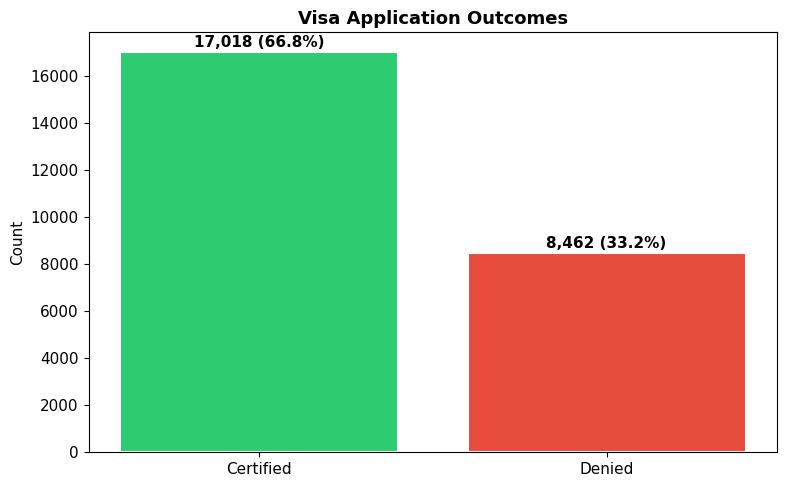

In [5]:
# 2.1 Class distribution
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(class_counts.index, class_counts.values,
              color=[COLOR_CERTIFIED if str(c).lower().startswith('certif') else COLOR_DENIED 
                     for c in class_counts.index],
              edgecolor='white', linewidth=1.5)
ax.set_title('Visa Application Outcomes', fontweight='bold')
ax.set_ylabel('Count')
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
            f'{count:,} ({count/len(df)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

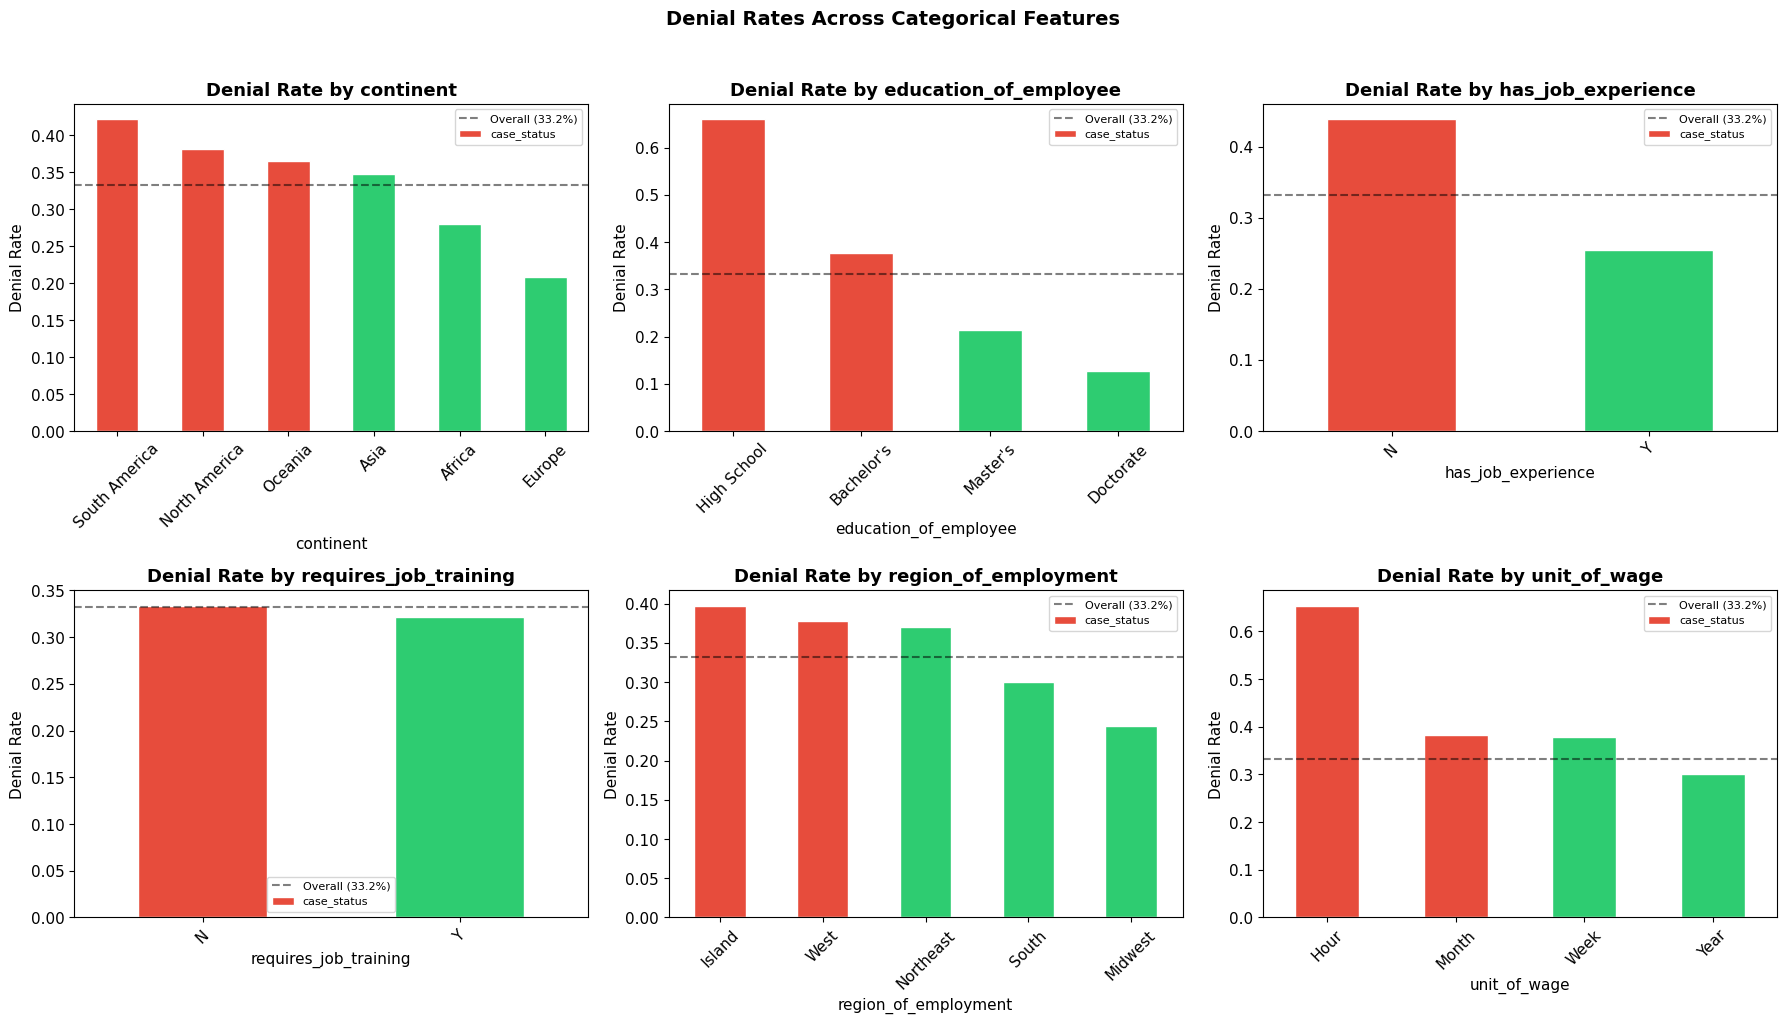

In [6]:
# 2.2 Categorical feature analysis — outcome rates by category
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != target_col and c.lower() != 'case_id']

# Also check for columns that look like IDs
id_cols = [c for c in df.columns if 'id' in c.lower() and df[c].nunique() > len(df) * 0.5]
cat_cols = [c for c in cat_cols if c not in id_cols]

n_cats = min(len(cat_cols), 6)
if n_cats > 0:
    rows = (n_cats + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows))
    axes = axes.flatten() if n_cats > 3 else [axes] if n_cats == 1 else axes.flatten()
    
    for idx, col in enumerate(cat_cols[:n_cats]):
        ax = axes[idx]
        # Calculate denial rate per category
        denial_rate = df.groupby(col)[target_col].apply(
            lambda x: (x == minority_class).mean()
        ).sort_values(ascending=False)
        
        colors = [COLOR_DENIED if r > denial_rate.median() else COLOR_CERTIFIED for r in denial_rate.values]
        denial_rate.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
        ax.set_title(f'Denial Rate by {col}', fontweight='bold')
        ax.set_ylabel('Denial Rate')
        ax.axhline(y=minority_pct/100, color='black', linestyle='--', alpha=0.5, label=f'Overall ({minority_pct:.1f}%)')
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=45)
    
    # Hide unused axes
    for idx in range(n_cats, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Denial Rates Across Categorical Features', fontweight='bold', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

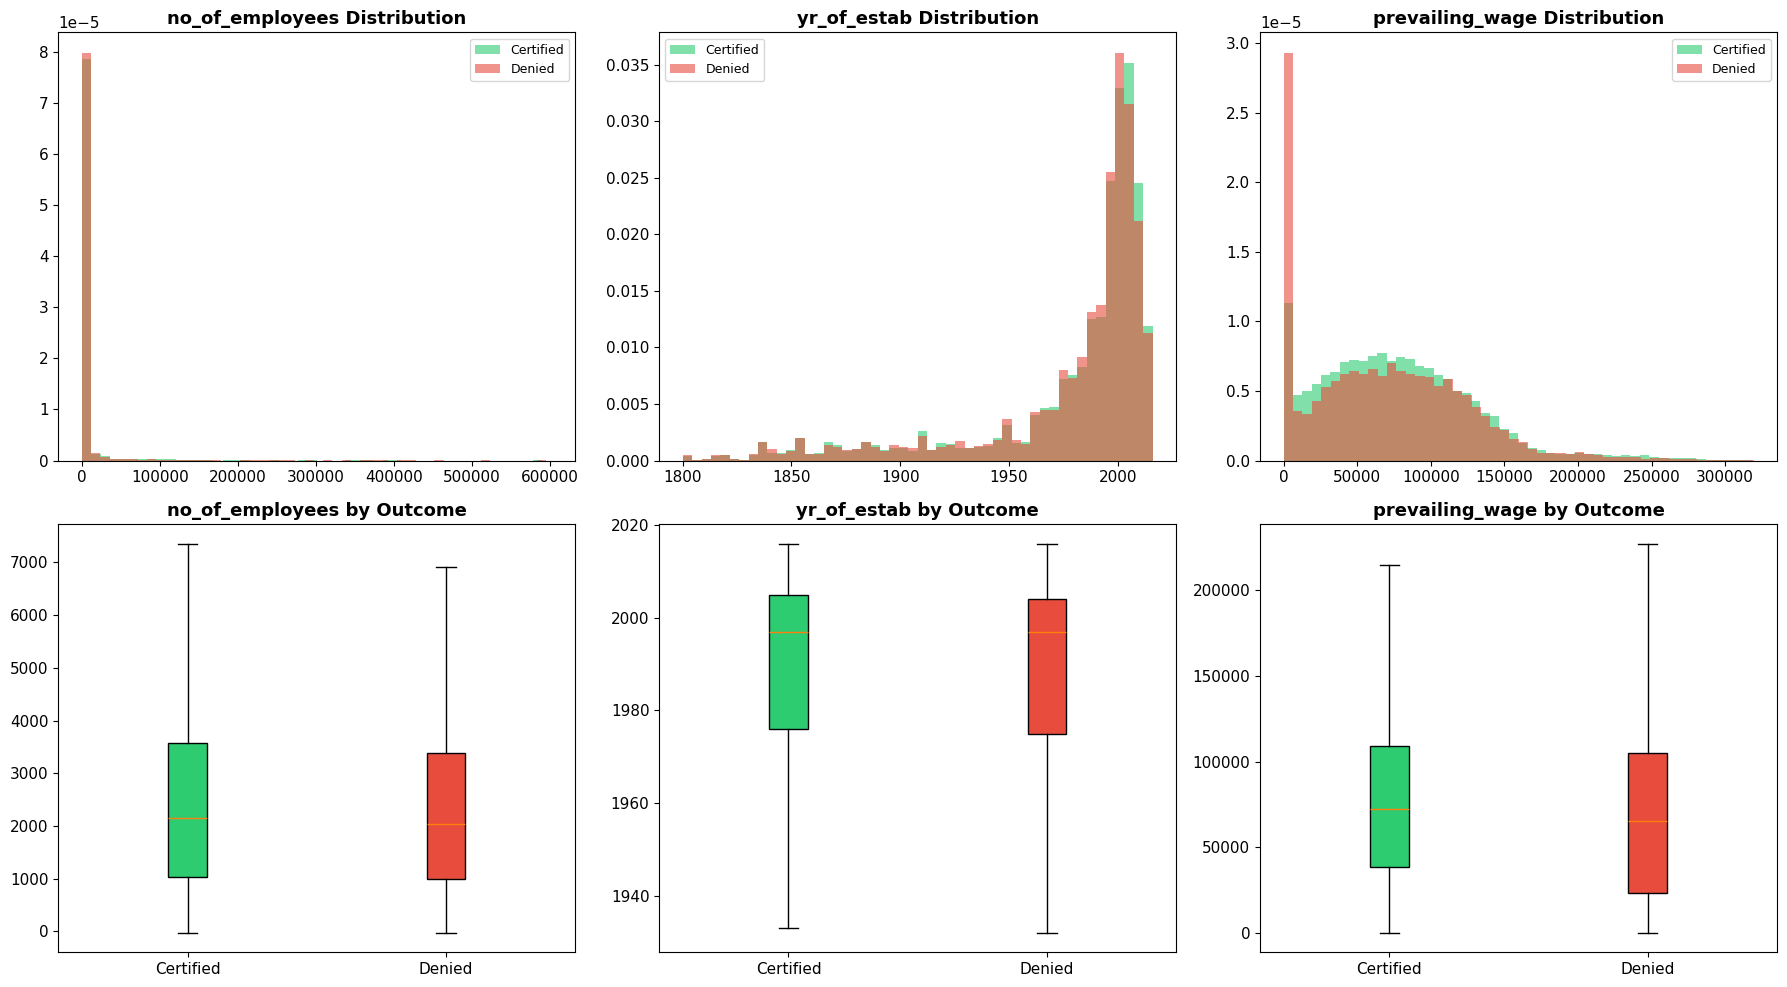

Numeric Feature Summary by Outcome:
------------------------------------------------------------
  no_of_employees                | Certified:      5,807.0 | Denied:      5,385.5
  yr_of_estab                    | Certified:      1,979.7 | Denied:      1,978.9
  prevailing_wage                | Certified:     77,293.6 | Denied:     68,748.7


In [7]:
# 2.3 Numeric feature analysis
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in id_cols and c != target_col]

if num_cols:
    n_nums = min(len(num_cols), 6)
    fig, axes = plt.subplots(2, min(n_nums, 3), figsize=(18, 10))
    if n_nums <= 3:
        axes = axes.reshape(2, -1)
    
    for idx, col in enumerate(num_cols[:min(n_nums, 3)]):
        # Distribution by outcome
        ax = axes[0][idx]
        for cls in [majority_class, minority_class]:
            color = COLOR_CERTIFIED if str(cls).lower().startswith('certif') else COLOR_DENIED
            label = str(cls)
            subset = df[df[target_col] == cls][col].dropna()
            ax.hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)
        ax.set_title(f'{col} Distribution', fontweight='bold')
        ax.legend(fontsize=9)
        
        # Box plot
        ax2 = axes[1][idx]
        data_groups = [df[df[target_col] == c][col].dropna() for c in [majority_class, minority_class]]
        bp = ax2.boxplot(data_groups, labels=[str(majority_class)[:10], str(minority_class)[:10]],
                         patch_artist=True, showfliers=False)
        bp['boxes'][0].set_facecolor(COLOR_CERTIFIED)
        bp['boxes'][1].set_facecolor(COLOR_DENIED)
        ax2.set_title(f'{col} by Outcome', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Summary stats
    print("Numeric Feature Summary by Outcome:")
    print("-" * 60)
    for col in num_cols:
        maj_mean = df[df[target_col] == majority_class][col].mean()
        min_mean = df[df[target_col] == minority_class][col].mean()
        print(f"  {col:30s} | {majority_class}: {maj_mean:>12,.1f} | {minority_class}: {min_mean:>12,.1f}")

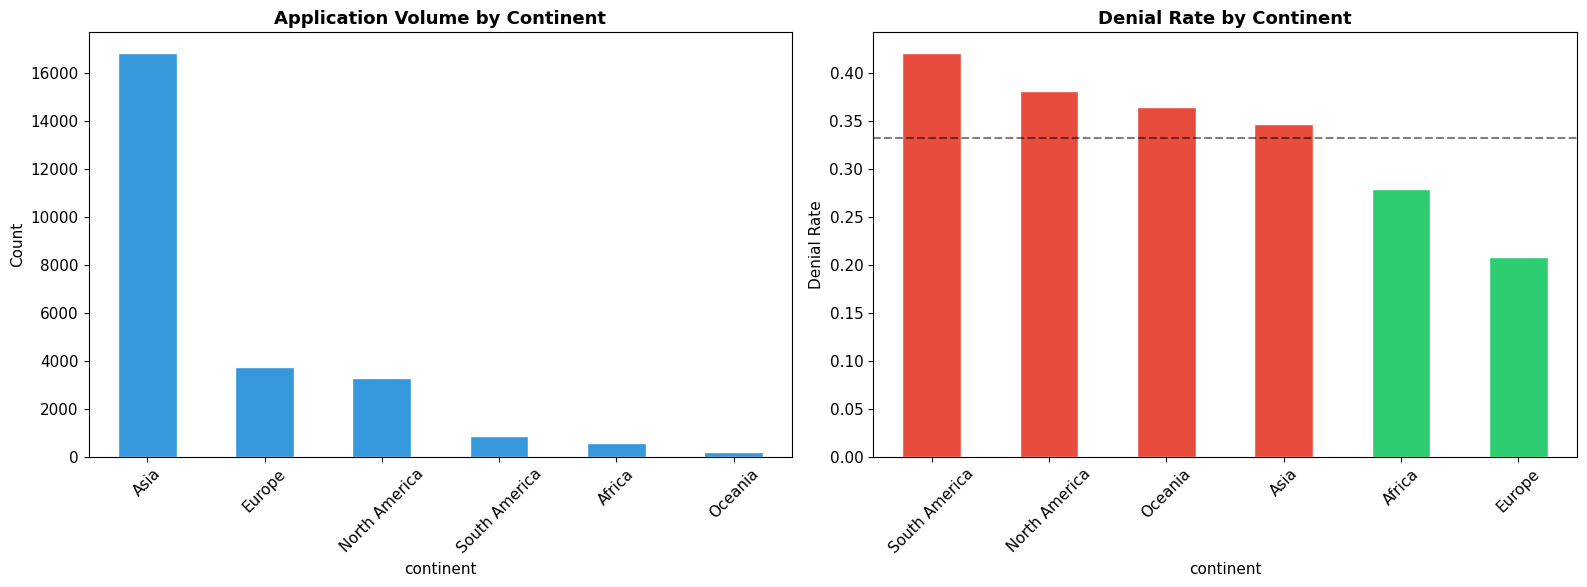


In Australian context: Home Affairs uses country risk assessments to inform
visa processing streams (evidenced by different document checklists by nationality).
This is NOT discrimination — it reflects historical compliance rates by cohort.


In [8]:
# 2.4 Continent / region of origin analysis
continent_col = [c for c in df.columns if 'continent' in c.lower()]
if continent_col:
    continent_col = continent_col[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Application volume by continent
    cont_counts = df[continent_col].value_counts()
    cont_counts.plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='white')
    axes[0].set_title('Application Volume by Continent', fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Denial rate by continent
    cont_denial = df.groupby(continent_col)[target_col].apply(
        lambda x: (x == minority_class).mean()
    ).sort_values(ascending=False)
    colors = [COLOR_DENIED if r > minority_pct/100 else COLOR_CERTIFIED for r in cont_denial.values]
    cont_denial.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
    axes[1].set_title('Denial Rate by Continent', fontweight='bold')
    axes[1].set_ylabel('Denial Rate')
    axes[1].axhline(y=minority_pct/100, color='black', linestyle='--', alpha=0.5)
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print("\nIn Australian context: Home Affairs uses country risk assessments to inform")
    print("visa processing streams (evidenced by different document checklists by nationality).")
    print("This is NOT discrimination — it reflects historical compliance rates by cohort.")

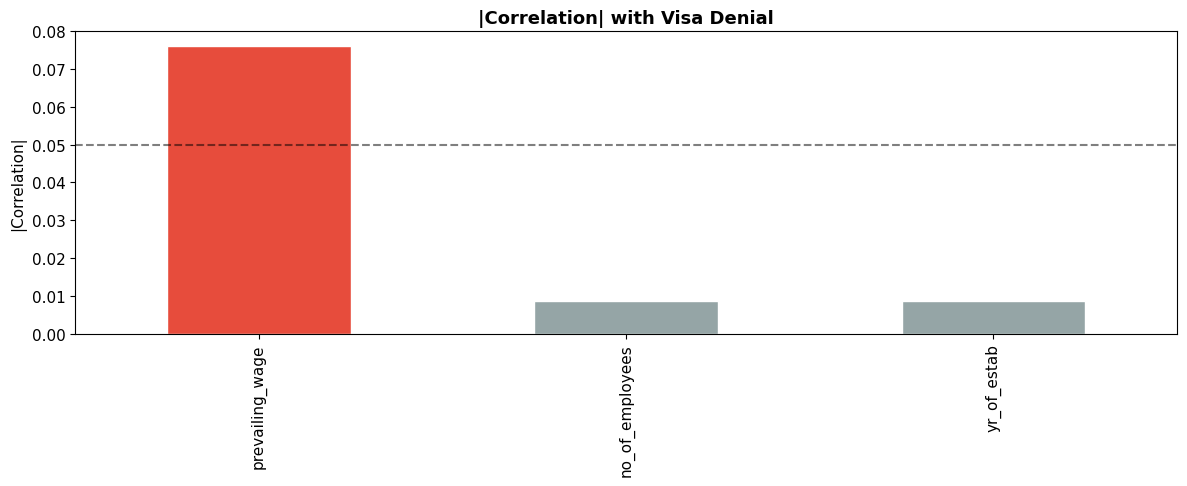

In [9]:
# 2.5 Correlation analysis — numeric features with target
# Encode target for correlation
target_binary = (df[target_col] == minority_class).astype(int)

if num_cols:
    correlations = df[num_cols].corrwith(target_binary).abs().sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    colors_corr = [COLOR_DENIED if c > 0.05 else '#95a5a6' for c in correlations.values]
    correlations.plot(kind='bar', ax=ax, color=colors_corr, edgecolor='white')
    ax.set_title('|Correlation| with Visa Denial', fontweight='bold')
    ax.set_ylabel('|Correlation|')
    ax.axhline(y=0.05, color='black', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

---
## 3. Feature Engineering & Preprocessing

Immigration feature engineering mirrors the risk factors that case officers assess:
- **Sponsor credibility** — business size, establishment year, history
- **Applicant profile** — education, experience, occupation demand
- **Economic alignment** — wage vs prevailing wage, full-time status
- **Geographic factors** — region of employment, origin country risk tier

In production, additional features would include: visa grant/refusal history, sponsor compliance record, occupation shortage lists (PMSOL/ROL equivalent), and biometric match scores.

In [10]:
# 3.1 Feature engineering
df_feat = df.copy()

# Drop ID columns
for col in id_cols:
    if col in df_feat.columns:
        df_feat.drop(col, axis=1, inplace=True)
# Also drop 'case_id' if present
if 'case_id' in df_feat.columns:
    df_feat.drop('case_id', axis=1, inplace=True)

# Wage normalization — convert all wages to annual equivalent
wage_col = [c for c in df_feat.columns if 'wage' in c.lower() and 'unit' not in c.lower()]
unit_col = [c for c in df_feat.columns if 'unit' in c.lower() and 'wage' in c.lower()]

if wage_col and unit_col:
    wage_col = wage_col[0]
    unit_col = unit_col[0]
    
    # Create annualized wage
    wage_multiplier = {
        'Year': 1, 'Month': 12, 'Week': 52, 'Hour': 2080  # 40hrs * 52 weeks
    }
    # Handle case-insensitive matching
    unit_map = {}
    for val in df_feat[unit_col].unique():
        for key, mult in wage_multiplier.items():
            if key.lower() in str(val).lower():
                unit_map[val] = mult
                break
        if val not in unit_map:
            unit_map[val] = 1  # default to annual
    
    df_feat['wage_annual'] = df_feat[wage_col] * df_feat[unit_col].map(unit_map)
    df_feat['wage_log'] = np.log1p(df_feat['wage_annual'])
    print(f"Annualized wage created from {wage_col} × {unit_col}")
    print(f"  Wage unit mapping: {unit_map}")

# Company age (years since establishment)
estab_col = [c for c in df_feat.columns if 'estab' in c.lower() or 'yr_of' in c.lower()]
if estab_col:
    estab_col = estab_col[0]
    current_year = df_feat[estab_col].max() + 5  # approximate
    df_feat['company_age'] = current_year - df_feat[estab_col]
    df_feat['company_age_log'] = np.log1p(df_feat['company_age'])

# Company size buckets
emp_col = [c for c in df_feat.columns if 'employee' in c.lower() and 'education' not in c.lower()]
if emp_col:
    emp_col = emp_col[0]
    # Use qcut for adaptive binning, then .cat.codes
    df_feat['company_size_bin'] = pd.qcut(df_feat[emp_col], q=5, duplicates='drop').cat.codes
    df_feat['employees_log'] = np.log1p(df_feat[emp_col].clip(lower=0))

# Wage per employee (proxy for company profitability)
if wage_col and emp_col:
    df_feat['wage_per_employee'] = df_feat['wage_annual'] / df_feat[emp_col].clip(lower=1)

new_features = [c for c in df_feat.columns if c not in df.columns]
print(f"\nEngineered {len(new_features)} new features: {new_features}")

Annualized wage created from prevailing_wage × unit_of_wage
  Wage unit mapping: {'Hour': 2080, 'Year': 1, 'Week': 52, 'Month': 12}

Engineered 7 new features: ['wage_annual', 'wage_log', 'company_age', 'company_age_log', 'company_size_bin', 'employees_log', 'wage_per_employee']


In [11]:
# 3.2 Encode categorical features
# Label encode all remaining object columns (except target)
label_encoders = {}
cat_feature_cols = [c for c in df_feat.select_dtypes(include=['object']).columns if c != target_col]

for col in cat_feature_cols:
    le = LabelEncoder()
    df_feat[col + '_encoded'] = le.fit_transform(df_feat[col].astype(str))
    label_encoders[col] = le
    print(f"  Encoded {col}: {len(le.classes_)} classes")

# Prepare feature matrix
drop_cols = [target_col] + cat_feature_cols  # drop original string columns
feature_cols = [c for c in df_feat.columns if c not in drop_cols
                and df_feat[c].dtype in ['int64', 'float64', 'int32', 'float32']]

# Encode target as binary (1 = denied/minority)
y = (df_feat[target_col] == minority_class).astype(int).values

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(df_feat[feature_cols].fillna(0))

print(f"\nFeature matrix: X={X.shape}, y={y.shape}")
print(f"Denial rate: {y.mean()*100:.2f}%")
print(f"\nFeatures ({len(feature_cols)}):")
for i, col in enumerate(feature_cols):
    print(f"  [{i:2d}] {col}")

  Encoded continent: 6 classes
  Encoded education_of_employee: 4 classes
  Encoded has_job_experience: 2 classes
  Encoded requires_job_training: 2 classes
  Encoded region_of_employment: 5 classes
  Encoded unit_of_wage: 4 classes
  Encoded full_time_position: 2 classes

Feature matrix: X=(25480, 16), y=(25480,)
Denial rate: 33.21%

Features (16):
  [ 0] no_of_employees
  [ 1] yr_of_estab
  [ 2] prevailing_wage
  [ 3] wage_annual
  [ 4] wage_log
  [ 5] company_age
  [ 6] company_age_log
  [ 7] employees_log
  [ 8] wage_per_employee
  [ 9] continent_encoded
  [10] education_of_employee_encoded
  [11] has_job_experience_encoded
  [12] requires_job_training_encoded
  [13] region_of_employment_encoded
  [14] unit_of_wage_encoded
  [15] full_time_position_encoded


---
## 4. Applicant Risk Profile Analysis

Before modelling, we need to understand what differentiates denied applications from certified ones. In Home Affairs, this maps to the "risk tier" concept — applications are streamed into low/medium/high risk queues based on applicant and sponsor profiles.

We use Cohen's d (effect size) to quantify the statistical separation between approved and denied applications across all features.

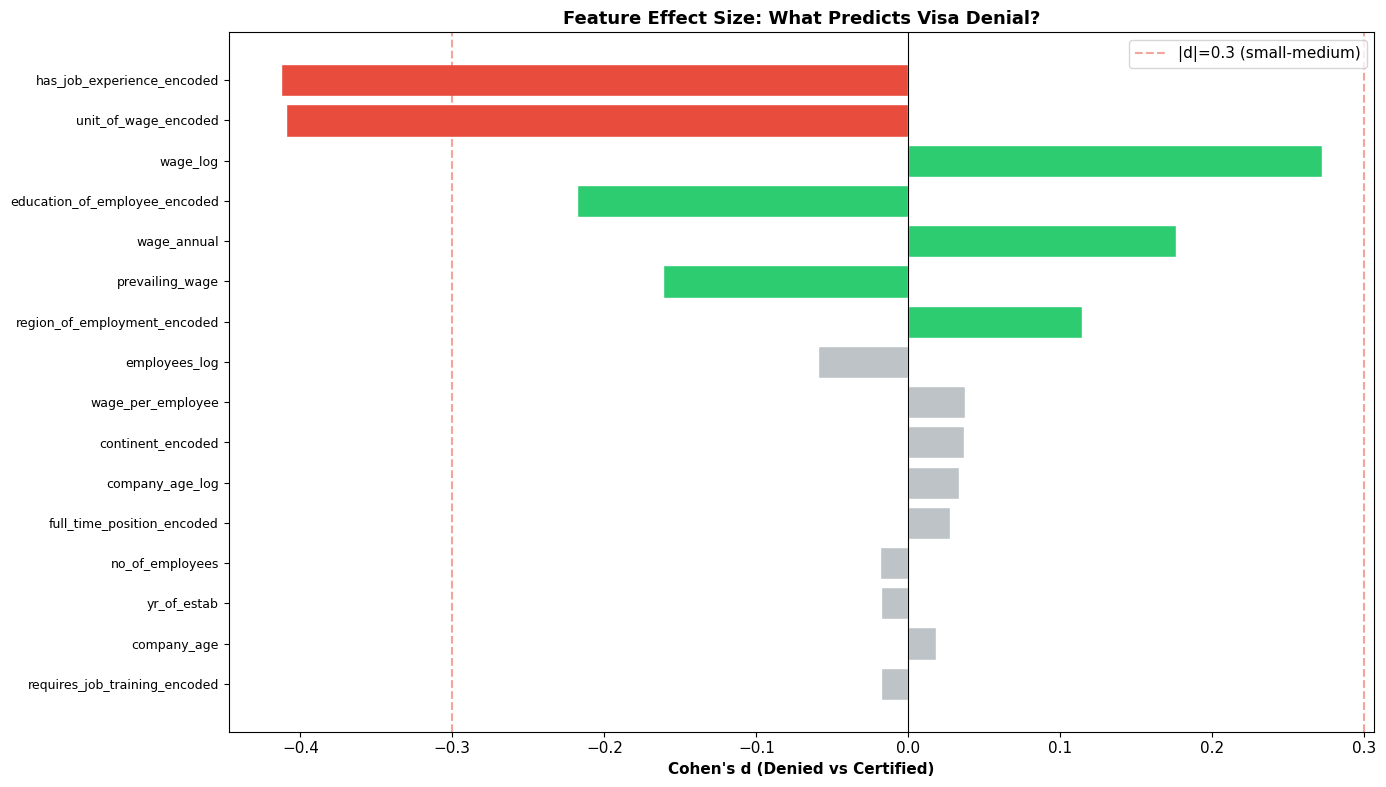


Top risk indicators (by |Cohen's d|):
  has_job_experience_encoded      d = -0.413  (LOWER for denials)
  unit_of_wage_encoded            d = -0.409  (LOWER for denials)
  wage_log                        d = +0.272  (HIGHER for denials)
  education_of_employee_encoded   d = -0.218  (LOWER for denials)
  wage_annual                     d = +0.176  (HIGHER for denials)
  prevailing_wage                 d = -0.161  (LOWER for denials)
  region_of_employment_encoded    d = +0.114  (HIGHER for denials)
  employees_log                   d = -0.059  (LOWER for denials)
  wage_per_employee               d = +0.037  (HIGHER for denials)
  continent_encoded               d = +0.037  (HIGHER for denials)


In [12]:
# 4.1 Cohen's d — effect size for all features
cohens_d_results = {}
for i, col in enumerate(feature_cols):
    approved_vals = X[y == 0, i]
    denied_vals = X[y == 1, i]
    
    app_mean, den_mean = approved_vals.mean(), denied_vals.mean()
    pooled_std = np.sqrt((approved_vals.std()**2 + denied_vals.std()**2) / 2)
    d = (den_mean - app_mean) / pooled_std if pooled_std > 0 else 0
    cohens_d_results[col] = d

sorted_effects = sorted(cohens_d_results.items(), key=lambda x: abs(x[1]), reverse=True)

fig, ax = plt.subplots(figsize=(14, 8))
features_sorted = [x[0] for x in sorted_effects]
effects_sorted = [x[1] for x in sorted_effects]
colors = [COLOR_DENIED if abs(d) > 0.3 else COLOR_CERTIFIED if abs(d) > 0.1 else '#bdc3c7' for d in effects_sorted]

ax.barh(range(len(features_sorted)), effects_sorted, color=colors, edgecolor='white')
ax.set_yticks(range(len(features_sorted)))
ax.set_yticklabels(features_sorted, fontsize=9)
ax.set_xlabel("Cohen's d (Denied vs Certified)", fontweight='bold')
ax.set_title("Feature Effect Size: What Predicts Visa Denial?", fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.axvline(x=0.3, color=COLOR_DENIED, linestyle='--', alpha=0.5, label='|d|=0.3 (small-medium)')
ax.axvline(x=-0.3, color=COLOR_DENIED, linestyle='--', alpha=0.5)
ax.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop risk indicators (by |Cohen's d|):")
for feat, d in sorted_effects[:10]:
    direction = "HIGHER for denials" if d > 0 else "LOWER for denials"
    print(f"  {feat:30s}  d = {d:+.3f}  ({direction})")

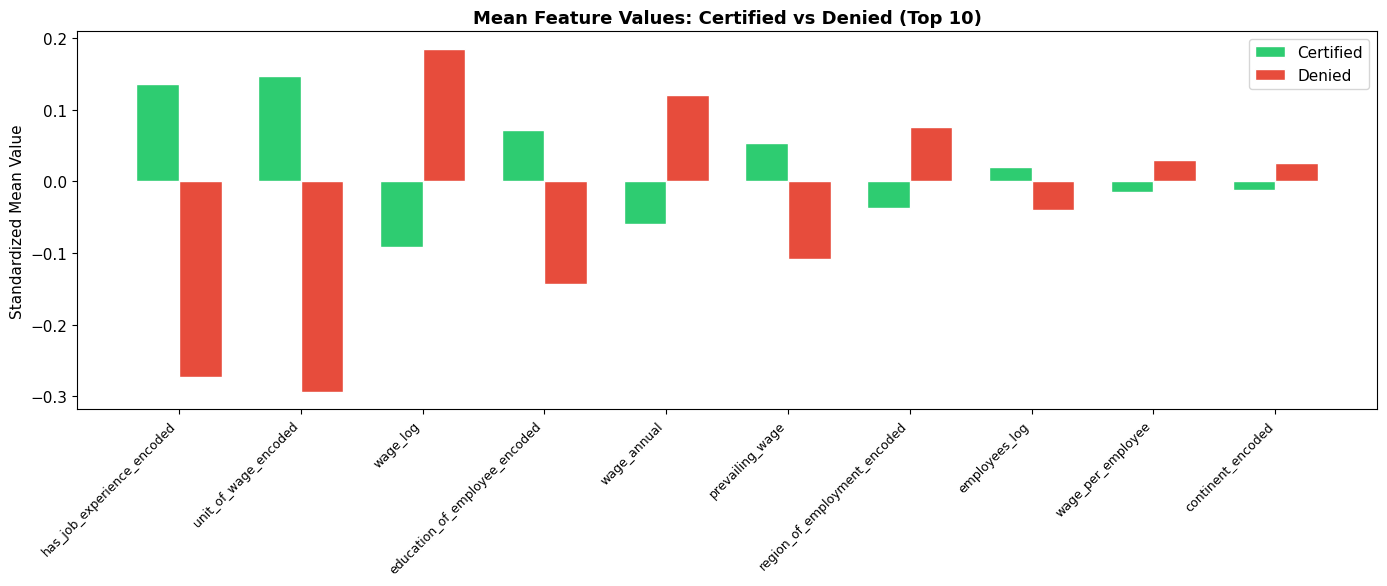

In [13]:
# 4.2 Risk profile comparison
top_10_feats = [x[0] for x in sorted_effects[:10]]
top_10_idx = [feature_cols.index(f) for f in top_10_feats]

fig, ax = plt.subplots(figsize=(14, 6))
x_pos = np.arange(len(top_10_feats))
width = 0.35

certified_means = [X[y == 0, i].mean() for i in top_10_idx]
denied_means = [X[y == 1, i].mean() for i in top_10_idx]

ax.bar(x_pos - width/2, certified_means, width, color=COLOR_CERTIFIED, label='Certified', edgecolor='white')
ax.bar(x_pos + width/2, denied_means, width, color=COLOR_DENIED, label='Denied', edgecolor='white')
ax.set_xticks(x_pos)
ax.set_xticklabels(top_10_feats, rotation=45, ha='right', fontsize=9)
ax.set_title('Mean Feature Values: Certified vs Denied (Top 10)', fontweight='bold')
ax.set_ylabel('Standardized Mean Value')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Model Training & Comparison

Four models for visa outcome prediction:
1. **Logistic Regression** — most interpretable, meets regulatory explainability requirements
2. **Random Forest** — captures non-linear interactions between features
3. **XGBoost** — gradient boosting with class imbalance handling
4. **LightGBM** — fast, production-friendly gradient boosting

In immigration contexts, **explainability is non-negotiable**. The Migration Act 1958 (Cth) s.66 requires written reasons for visa refusal. A pure black-box model cannot satisfy this — but it can *support* case officer decision-making by flagging risk factors.

In [14]:
# 5.1 Model definitions
n_denied = y.sum()
n_certified = (1 - y).sum()
scale_ratio = n_certified / n_denied

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42,
        n_jobs=-1, max_depth=10, min_samples_leaf=5
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100, scale_pos_weight=scale_ratio,
        random_state=42, eval_metric='logloss',
        max_depth=6, learning_rate=0.1, n_jobs=-1, verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=100, class_weight='balanced',
        random_state=42, max_depth=-1, learning_rate=0.05,
        n_jobs=-1, verbose=-1, num_leaves=31, min_child_samples=5,
        reg_alpha=0.1, reg_lambda=1.0
    )
}

print(f"Class imbalance ratio: 1:{scale_ratio:.1f}")
print(f"Training samples: {len(X):,}")
print(f"Features: {X.shape[1]}")
print(f"CV strategy: 3-fold StratifiedKFold")

Class imbalance ratio: 1:2.0
Training samples: 25,480
Features: 16
CV strategy: 3-fold StratifiedKFold


In [15]:
# 5.2 Manual 3-fold CV with OOF predictions
import time
from sklearn.base import clone

N_FOLDS = 3
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

results = {}
oof_preds = {}
oof_probs = {}

for model_name, model_template in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    
    oof_pred = np.zeros(len(y), dtype=int)
    oof_prob = np.zeros(len(y), dtype=float)
    fold_metrics = []
    start_time = time.time()
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model = clone(model_template)
        model.fit(X_train, y_train)
        
        pred = model.predict(X_val)
        prob = model.predict_proba(X_val)[:, 1]
        
        oof_pred[val_idx] = pred
        oof_prob[val_idx] = prob
        
        fold_f1 = f1_score(y_val, pred)
        fold_prauc = average_precision_score(y_val, prob)
        fold_rocauc = roc_auc_score(y_val, prob)
        fold_recall = recall_score(y_val, pred)
        fold_precision = precision_score(y_val, pred)
        
        print(f"  Fold {fold+1}: F1={fold_f1:.4f} | PR-AUC={fold_prauc:.4f} | "
              f"ROC-AUC={fold_rocauc:.4f} | Recall={fold_recall:.4f} | Prec={fold_precision:.4f}")
        
        fold_metrics.append({
            'f1': fold_f1, 'pr_auc': fold_prauc, 'roc_auc': fold_rocauc,
            'recall': fold_recall, 'precision': fold_precision
        })
    
    elapsed = time.time() - start_time
    
    oof_results = {
        'accuracy': accuracy_score(y, oof_pred),
        'precision': precision_score(y, oof_pred, zero_division=0),
        'recall': recall_score(y, oof_pred, zero_division=0),
        'f1': f1_score(y, oof_pred, zero_division=0),
        'roc_auc': roc_auc_score(y, oof_prob),
        'pr_auc': average_precision_score(y, oof_prob),
        'brier': brier_score_loss(y, oof_prob),
        'time': elapsed
    }
    
    results[model_name] = oof_results
    oof_preds[model_name] = oof_pred
    oof_probs[model_name] = oof_prob
    
    print(f"\n  OOF: F1={oof_results['f1']:.4f} | PR-AUC={oof_results['pr_auc']:.4f} | "
          f"ROC-AUC={oof_results['roc_auc']:.4f} | Time={elapsed:.1f}s")


Training: Logistic Regression
  Fold 1: F1=0.5138 | PR-AUC=0.5115 | ROC-AUC=0.6678 | Recall=0.5721 | Prec=0.4663
  Fold 2: F1=0.5078 | PR-AUC=0.5062 | ROC-AUC=0.6626 | Recall=0.5544 | Prec=0.4684
  Fold 3: F1=0.5105 | PR-AUC=0.5076 | ROC-AUC=0.6635 | Recall=0.5578 | Prec=0.4707

  OOF: F1=0.5108 | PR-AUC=0.5079 | ROC-AUC=0.6643 | Time=0.1s

Training: Random Forest
  Fold 1: F1=0.6077 | PR-AUC=0.6069 | ROC-AUC=0.7749 | Recall=0.6537 | Prec=0.5677
  Fold 2: F1=0.6091 | PR-AUC=0.6117 | ROC-AUC=0.7723 | Recall=0.6423 | Prec=0.5791
  Fold 3: F1=0.5992 | PR-AUC=0.5970 | ROC-AUC=0.7644 | Recall=0.6223 | Prec=0.5777

  OOF: F1=0.6054 | PR-AUC=0.6040 | ROC-AUC=0.7704 | Time=3.4s

Training: XGBoost
  Fold 1: F1=0.6168 | PR-AUC=0.6303 | ROC-AUC=0.7845 | Recall=0.6788 | Prec=0.5652
  Fold 2: F1=0.6148 | PR-AUC=0.6281 | ROC-AUC=0.7769 | Recall=0.6803 | Prec=0.5608
  Fold 3: F1=0.6039 | PR-AUC=0.6102 | ROC-AUC=0.7706 | Recall=0.6479 | Prec=0.5655

  OOF: F1=0.6119 | PR-AUC=0.6220 | ROC-AUC=0.7772 |

In [16]:
# 5.3 Results comparison
print("\n" + "=" * 95)
print("MODEL COMPARISON (OOF Results)")
print("=" * 95)
print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9} {'PR-AUC':>9} {'Brier':>8} {'Time':>7}")
print("-" * 95)

for name, res in results.items():
    print(f"{name:<22} {res['accuracy']:>9.4f} {res['precision']:>10.4f} {res['recall']:>8.4f} "
          f"{res['f1']:>8.4f} {res['roc_auc']:>9.4f} {res['pr_auc']:>9.4f} {res['brier']:>8.4f} {res['time']:>6.1f}s")

best_model = max(results.items(), key=lambda x: x[1]['pr_auc'])
print(f"\nBest model by PR-AUC: {best_model[0]} ({best_model[1]['pr_auc']:.4f})")


MODEL COMPARISON (OOF Results)
Model                   Accuracy  Precision   Recall       F1   ROC-AUC    PR-AUC    Brier    Time
-----------------------------------------------------------------------------------------------
Logistic Regression       0.6428     0.4684   0.5615   0.5108    0.6643    0.5079   0.2275    0.1s
Random Forest             0.7231     0.5747   0.6394   0.6054    0.7704    0.6040   0.1928    3.4s
XGBoost                   0.7182     0.5638   0.6690   0.6119    0.7772    0.6220   0.1893    0.9s
LightGBM                  0.7215     0.5684   0.6709   0.6154    0.7829    0.6330   0.1889    0.9s

Best model by PR-AUC: LightGBM (0.6330)


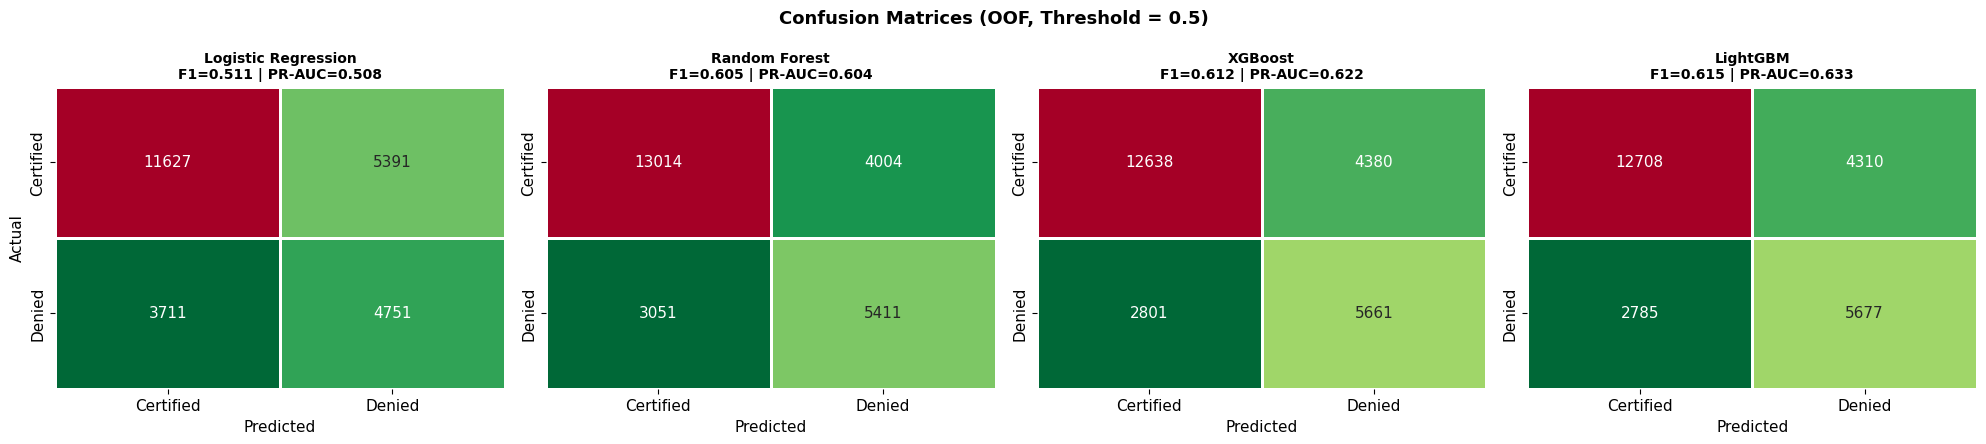

In [17]:
# 5.4 Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for idx, (name, pred) in enumerate(oof_preds.items()):
    cm = confusion_matrix(y, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', ax=axes[idx],
                xticklabels=['Certified', 'Denied'], yticklabels=['Certified', 'Denied'],
                cbar=False, linewidths=1, linecolor='white')
    axes[idx].set_title(f'{name}\nF1={results[name]["f1"]:.3f} | PR-AUC={results[name]["pr_auc"]:.3f}',
                        fontweight='bold', fontsize=10)
    axes[idx].set_ylabel('Actual' if idx == 0 else '')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices (OOF, Threshold = 0.5)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

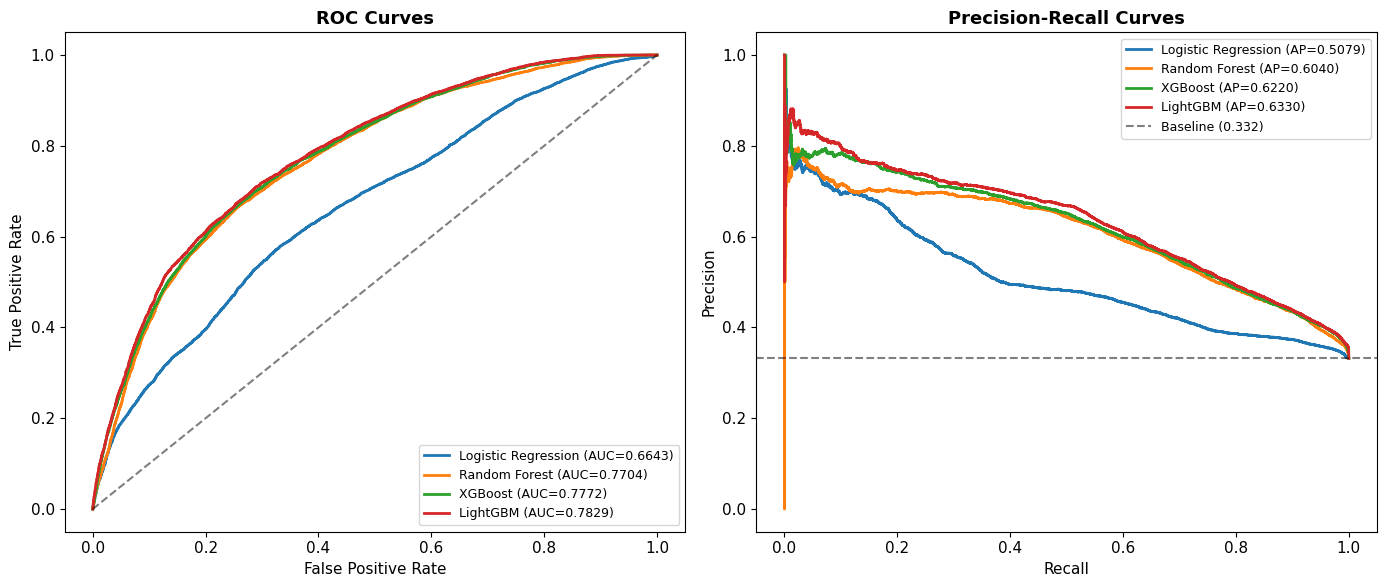

In [18]:
# 5.5 ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, prob in oof_probs.items():
    fpr, tpr, _ = roc_curve(y, prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={results[name]['roc_auc']:.4f})", linewidth=2)
    
    prec, rec, _ = precision_recall_curve(y, prob)
    axes[1].plot(rec, prec, label=f"{name} (AP={results[name]['pr_auc']:.4f})", linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9, loc='lower right')

baseline = y.mean()
axes[1].axhline(y=baseline, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline:.3f})')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

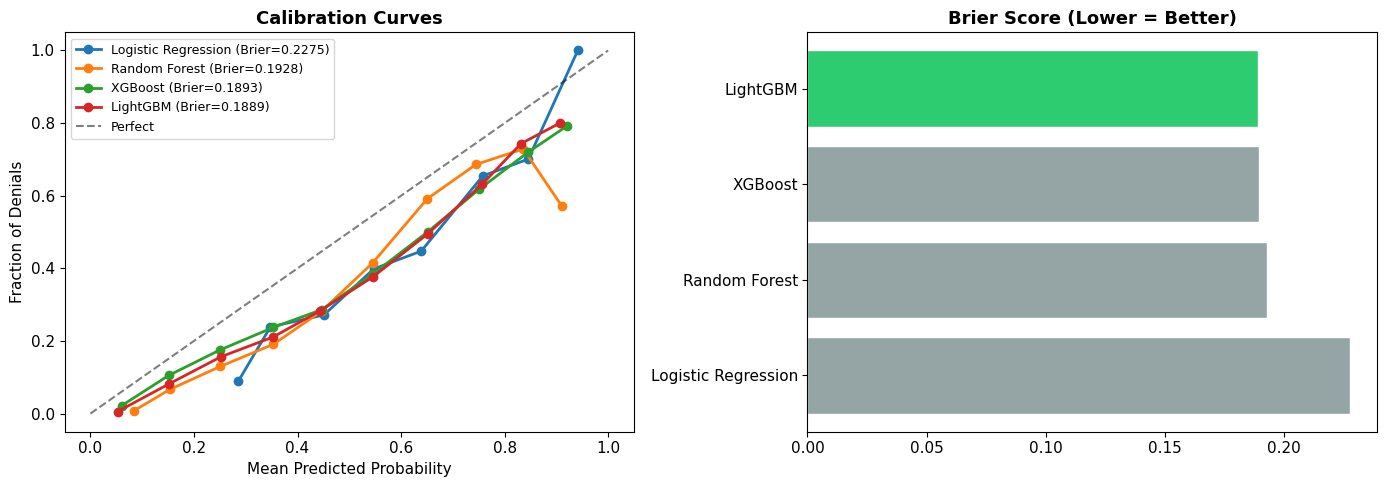


Calibration matters for immigration: a risk score of 0.7 should mean ~70% of
similar applications were historically denied. Poor calibration misleads case officers.


In [19]:
# 5.6 Calibration curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, prob in oof_probs.items():
    prob_true, prob_pred = calibration_curve(y, prob, n_bins=10, strategy='uniform')
    axes[0].plot(prob_pred, prob_true, marker='o', label=f"{name} (Brier={results[name]['brier']:.4f})", linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
axes[0].set_title('Calibration Curves', fontweight='bold')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Denials')
axes[0].legend(fontsize=9)

names = list(results.keys())
brier_scores = [results[n]['brier'] for n in names]
colors_b = [COLOR_CERTIFIED if b == min(brier_scores) else '#95a5a6' for b in brier_scores]
axes[1].barh(names, brier_scores, color=colors_b, edgecolor='white')
axes[1].set_title('Brier Score (Lower = Better)', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nCalibration matters for immigration: a risk score of 0.7 should mean ~70% of")
print("similar applications were historically denied. Poor calibration misleads case officers.")

---
## 6. Threshold Tuning & Cost-Sensitive Analysis

In immigration risk scoring, the threshold determines the sensitivity of the risk-tiering system:

| Scenario | Priority | Threshold |
|----------|----------|-----------|
| **National security stream** | Maximize detection of high-risk applicants | Low threshold (0.2–0.3) |
| **Balanced processing** | Efficient case officer allocation | Optimal F1 threshold |
| **Fast-track stream** (e.g., ETA/eVisitor) | Minimize legitimate applicant delays | Higher threshold (0.6–0.8) |

The cost asymmetry:
- **False Negative** (approving a high-risk applicant) → compliance breach, overstay, potential security risk
- **False Positive** (flagging a legitimate applicant) → processing delay, diplomatic friction, poor client service

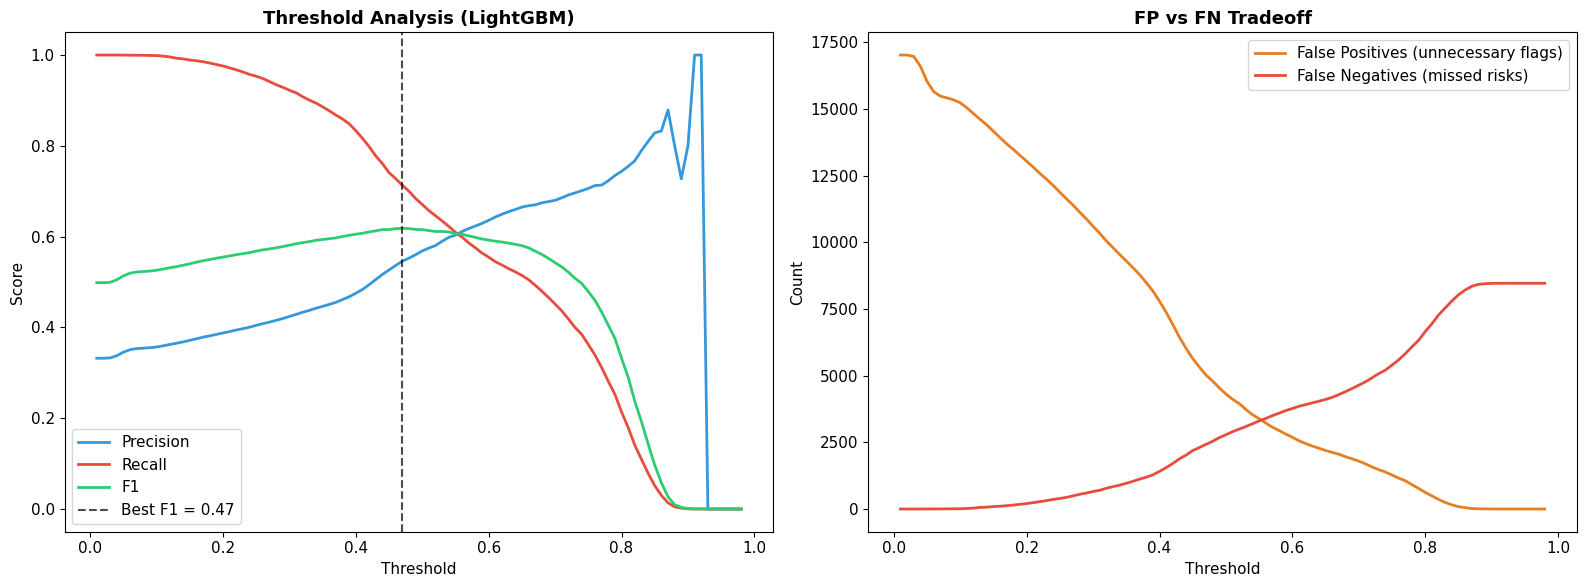

Optimal F1 threshold: 0.47


In [20]:
# 6.1 Threshold analysis
best_name = best_model[0]
best_prob = oof_probs[best_name]

thresholds = np.arange(0.01, 0.99, 0.01)
threshold_results = []

for thresh in thresholds:
    pred_t = (best_prob >= thresh).astype(int)
    tp = ((pred_t == 1) & (y == 1)).sum()
    fp = ((pred_t == 1) & (y == 0)).sum()
    fn = ((pred_t == 0) & (y == 1)).sum()
    tn = ((pred_t == 0) & (y == 0)).sum()
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_val = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    
    threshold_results.append({
        'threshold': thresh, 'precision': prec, 'recall': rec, 'f1': f1_val,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
    })

thr_df = pd.DataFrame(threshold_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(thr_df['threshold'], thr_df['precision'], color='#3498db', label='Precision', linewidth=2)
axes[0].plot(thr_df['threshold'], thr_df['recall'], color=COLOR_DENIED, label='Recall', linewidth=2)
axes[0].plot(thr_df['threshold'], thr_df['f1'], color=COLOR_CERTIFIED, label='F1', linewidth=2)
best_f1_idx = thr_df['f1'].idxmax()
best_f1_thresh = thr_df.loc[best_f1_idx, 'threshold']
axes[0].axvline(x=best_f1_thresh, color='black', linestyle='--', alpha=0.7,
                label=f'Best F1 = {best_f1_thresh:.2f}')
axes[0].set_title(f'Threshold Analysis ({best_name})', fontweight='bold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].legend()

axes[1].plot(thr_df['threshold'], thr_df['fp'], color='#e67e22', label='False Positives (unnecessary flags)', linewidth=2)
axes[1].plot(thr_df['threshold'], thr_df['fn'], color=COLOR_DENIED, label='False Negatives (missed risks)', linewidth=2)
axes[1].set_title('FP vs FN Tradeoff', fontweight='bold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Optimal F1 threshold: {best_f1_thresh:.2f}")

In [21]:
# 6.2 Immigration processing scenarios
COST_FN_SECURITY = 100000   # Missed high-risk: overstay, compliance breach, security incident
COST_FN_STANDARD = 25000    # Missed risk: visa condition breach, overstay
COST_FP = 500               # Unnecessary manual review: case officer hours + applicant delay
COST_TP = 200               # Correctly flagged: efficient targeted review

scenarios = {
    'National Security (max recall)': (0.15, COST_FN_SECURITY),
    'Balanced (Best F1)': (best_f1_thresh, COST_FN_STANDARD),
    'Standard Processing': (0.40, COST_FN_STANDARD),
    'Fast-Track / ETA Stream': (0.70, COST_FN_STANDARD),
}

print("=" * 95)
print("IMMIGRATION PROCESSING SCENARIO ANALYSIS")
print("=" * 95)
print(f"\n{'Scenario':<38} {'Thresh':>7} {'Recall':>8} {'Prec':>8} {'FP':>7} {'FN':>5} {'Est. Cost':>12}")
print("-" * 95)

for name, (thresh, fn_cost) in scenarios.items():
    row = thr_df.iloc[(thr_df['threshold'] - thresh).abs().argsort()[:1]].iloc[0]
    total_cost = row['fn'] * fn_cost + row['fp'] * COST_FP + row['tp'] * COST_TP
    print(f"{name:<38} {thresh:>7.2f} {row['recall']:>8.4f} {row['precision']:>8.4f} "
          f"{int(row['fp']):>7,} {int(row['fn']):>5,} ${total_cost:>10,.0f}")

print(f"\nKey: The national security stream flags more applications for manual review (higher FP)")
print(f"but catches nearly all high-risk cases. Fast-track lets most through with minimal friction.")

IMMIGRATION PROCESSING SCENARIO ANALYSIS

Scenario                                Thresh   Recall     Prec      FP    FN    Est. Cost
-----------------------------------------------------------------------------------------------
National Security (max recall)            0.15   0.9890   0.3715  14,160    93 $18,053,800
Balanced (Best F1)                        0.47   0.7133   0.5458   5,024 2,426 $64,369,200
Standard Processing                       0.40   0.8335   0.4752   7,788 1,409 $40,529,600
Fast-Track / ETA Stream                   0.70   0.4514   0.6801   1,797 4,642 $117,712,500

Key: The national security stream flags more applications for manual review (higher FP)
but catches nearly all high-risk cases. Fast-track lets most through with minimal friction.


---
## 7. Model Interpretability & Fairness

Immigration ML systems face intense scrutiny on two fronts:

1. **Explainability** — Migration Act s.66 requires reasons for refusal. The AAT/ART will review whether the decision-making process was lawful and reasonable.

2. **Fairness** — The Racial Discrimination Act 1975, Sex Discrimination Act 1984, and Disability Discrimination Act 1992 prohibit discrimination. A model that disproportionately flags applicants from certain regions needs careful auditing.

In practice, immigration risk models should be *decision-support tools*, not *decision-makers*. The case officer retains authority and accountability.

In [22]:
# 7.1 Feature importance
importances = {}

lr_final = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
lr_final.fit(X, y)
importances['Logistic Regression'] = np.abs(lr_final.coef_[0])

rf_final = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42,
                                   n_jobs=-1, max_depth=10, min_samples_leaf=5)
rf_final.fit(X, y)
importances['Random Forest'] = rf_final.feature_importances_

xgb_final = xgb.XGBClassifier(n_estimators=100, scale_pos_weight=scale_ratio,
                                random_state=42, eval_metric='logloss',
                                max_depth=6, learning_rate=0.1, n_jobs=-1, verbosity=0)
xgb_final.fit(X, y)
importances['XGBoost'] = xgb_final.feature_importances_

lgb_final = lgb.LGBMClassifier(n_estimators=100, class_weight='balanced',
                                 random_state=42, max_depth=-1, learning_rate=0.05,
                                 n_jobs=-1, verbose=-1, num_leaves=31, min_child_samples=5,
                                 reg_alpha=0.1, reg_lambda=1.0)
lgb_final.fit(X, y)
importances['LightGBM'] = lgb_final.feature_importances_

print("Feature importances extracted from all 4 models.")

Feature importances extracted from all 4 models.


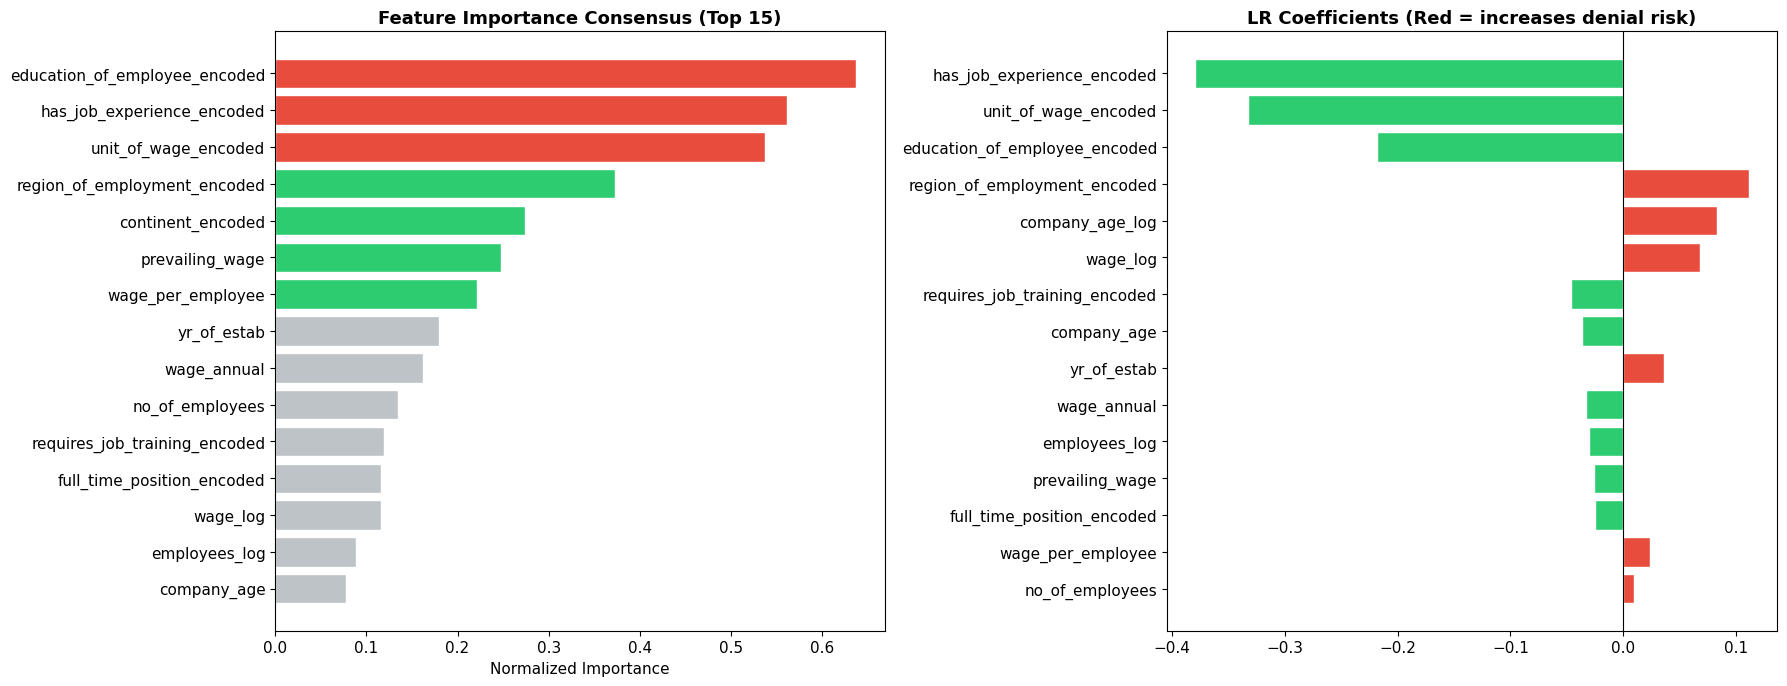


Top 5 risk drivers (consensus across all models):
  [1] education_of_employee_encoded (importance: 0.637)
  [2] has_job_experience_encoded (importance: 0.561)
  [3] unit_of_wage_encoded (importance: 0.537)
  [4] region_of_employment_encoded (importance: 0.373)
  [5] continent_encoded (importance: 0.274)


In [23]:
# 7.2 Consensus importance
norm_importances = {}
for name, imp in importances.items():
    imp_max = imp.max()
    norm_importances[name] = imp / imp_max if imp_max > 0 else imp

avg_importance = np.mean([norm_importances[m] for m in norm_importances], axis=0)
sorted_idx = np.argsort(avg_importance)[::-1][:15]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_features_names = [feature_cols[i] for i in sorted_idx]
top_features_vals = avg_importance[sorted_idx]
colors_imp = [COLOR_DENIED if v > 0.4 else COLOR_CERTIFIED if v > 0.2 else '#bdc3c7' for v in top_features_vals]

axes[0].barh(range(len(top_features_names)), top_features_vals, color=colors_imp, edgecolor='white')
axes[0].set_yticks(range(len(top_features_names)))
axes[0].set_yticklabels(top_features_names)
axes[0].set_title('Feature Importance Consensus (Top 15)', fontweight='bold')
axes[0].set_xlabel('Normalized Importance')
axes[0].invert_yaxis()

lr_coefs = lr_final.coef_[0]
lr_sorted_idx = np.argsort(np.abs(lr_coefs))[::-1][:15]
lr_feat_names = [feature_cols[i] for i in lr_sorted_idx]
lr_coef_vals = lr_coefs[lr_sorted_idx]
lr_colors = [COLOR_DENIED if c > 0 else COLOR_CERTIFIED for c in lr_coef_vals]

axes[1].barh(range(len(lr_feat_names)), lr_coef_vals, color=lr_colors, edgecolor='white')
axes[1].set_yticks(range(len(lr_feat_names)))
axes[1].set_yticklabels(lr_feat_names)
axes[1].set_title('LR Coefficients (Red = increases denial risk)', fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nTop 5 risk drivers (consensus across all models):")
for i, feat in enumerate(top_features_names[:5]):
    print(f"  [{i+1}] {feat} (importance: {top_features_vals[i]:.3f})")

In [24]:
# 7.3 Fairness audit — denial rates by sensitive attributes
print("=" * 70)
print("FAIRNESS AUDIT")
print("=" * 70)

# Check continent-based disparities
if continent_col:
    print(f"\nDenial rates by {continent_col}:")
    for cont in df[continent_col].unique():
        mask = df[continent_col] == cont
        actual_denial = (df.loc[mask, target_col] == minority_class).mean()
        pred_denial = oof_probs[best_name][mask.values].mean()
        n_apps = mask.sum()
        print(f"  {cont:20s} | n={n_apps:>5,} | Actual denial: {actual_denial:.3f} | "
              f"Model avg score: {pred_denial:.3f} | Gap: {pred_denial - actual_denial:+.3f}")

# Check education-based disparities
edu_col = [c for c in df.columns if 'education' in c.lower()]
if edu_col:
    edu_col = edu_col[0]
    print(f"\nDenial rates by {edu_col}:")
    for edu in df[edu_col].unique():
        mask = df[edu_col] == edu
        actual_denial = (df.loc[mask, target_col] == minority_class).mean()
        pred_denial = oof_probs[best_name][mask.values].mean()
        n_apps = mask.sum()
        print(f"  {str(edu):30s} | n={n_apps:>5,} | Actual: {actual_denial:.3f} | "
              f"Model: {pred_denial:.3f} | Gap: {pred_denial - actual_denial:+.3f}")

print(f"\nFairness note: Small gaps between actual and predicted denial rates indicate")
print(f"the model is not introducing systematic bias beyond what exists in historical data.")
print(f"However, historical data itself may contain biases that need policy-level review.")

FAIRNESS AUDIT

Denial rates by continent:
  Asia                 | n=16,861 | Actual denial: 0.347 | Model avg score: 0.469 | Gap: +0.122
  Africa               | n=  551 | Actual denial: 0.279 | Model avg score: 0.409 | Gap: +0.130
  North America        | n=3,292 | Actual denial: 0.381 | Model avg score: 0.507 | Gap: +0.126
  Europe               | n=3,732 | Actual denial: 0.208 | Model avg score: 0.333 | Gap: +0.125
  South America        | n=  852 | Actual denial: 0.421 | Model avg score: 0.538 | Gap: +0.117
  Oceania              | n=  192 | Actual denial: 0.365 | Model avg score: 0.509 | Gap: +0.145

Denial rates by education_of_employee:
  High School                    | n=3,420 | Actual: 0.660 | Model: 0.770 | Gap: +0.110
  Master's                       | n=9,634 | Actual: 0.214 | Model: 0.325 | Gap: +0.112
  Bachelor's                     | n=10,234 | Actual: 0.378 | Model: 0.522 | Gap: +0.144
  Doctorate                      | n=2,192 | Actual: 0.128 | Model: 0.228 | Gap: 

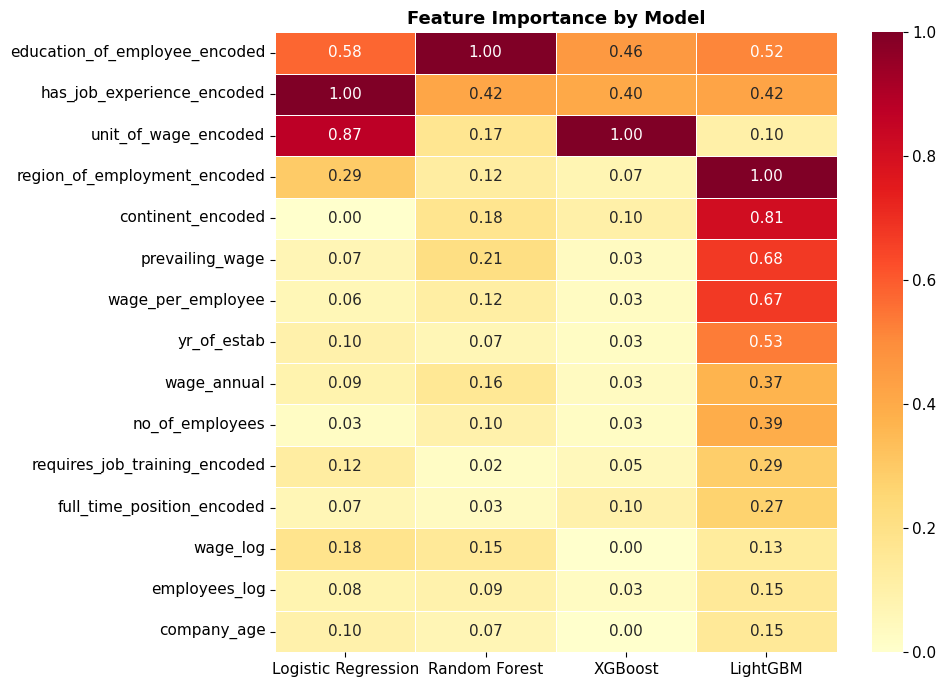

In [25]:
# 7.4 Per-model importance heatmap
top_n = min(15, len(feature_cols))
top_idx_hm = np.argsort(avg_importance)[::-1][:top_n]
top_names_hm = [feature_cols[i] for i in top_idx_hm]

heatmap_data = pd.DataFrame({
    name: [norm_importances[name][i] for i in top_idx_hm]
    for name in norm_importances
}, index=top_names_hm)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white', vmin=0, vmax=1)
ax.set_title('Feature Importance by Model', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Production Deployment Considerations

Deploying ML in immigration processing involves some of the most complex regulatory, ethical, and technical constraints in government.

### Risk-Tiered Processing Architecture

```
Visa Application Lodged (ImmiAccount / paper)
    │
    ▼
Identity Verification (biometrics, travel docs)
    │
    ▼
Automated Risk Scoring Engine
    │
    ├── LOW RISK (score < 0.2) ──► Auto-assessment queue
    │       └── Streamlined checks, minimal case officer time
    │
    ├── MEDIUM RISK (0.2 ≤ score < 0.6) ──► Standard processing
    │       └── Full case officer review, standard checks
    │
    └── HIGH RISK (score ≥ 0.6) ──► Enhanced scrutiny
            ├── Senior case officer review
            ├── External security checks (ASIO, AFP, Interpol)
            ├── Additional document verification
            └── Possible interview / s.56 request
    │
    ▼
Decision (Grant / Refuse / Request Further Information)
    │
    ▼
Review Rights (AAT/ART, Federal Court, Ministerial Intervention)
```

### Regulatory Framework (Australian Immigration)

| Legislation / Framework | Authority | Relevance |
|------------------------|-----------|-----------|
| **Migration Act 1958** | Parliament | Primary legislation governing all visa decisions |
| **Migration Regulations 1994** | DHA | Visa subclass criteria, schedule requirements |
| **Privacy Act 1988** | OAIC | Collection, use, disclosure of personal information |
| **AI Ethics Framework** | DISR | Principles for responsible AI in government |
| **ISM** | ASD | Security classification and data handling |
| **FOI Act 1982** | OAIC | Transparency in government decision-making |

### Key Production Considerations

**Explainability Mandate:** Every visa refusal must include written reasons (Migration Act s.66). The ML system must provide feature-level explanations for each risk score. SHAP values or LR coefficients can serve this purpose.

**Bias Monitoring:** Continuous monitoring for disparate impact across nationality, gender, and age cohorts. Regulatory review by the Commonwealth Ombudsman if patterns emerge.

**Data Sovereignty:** Immigration data is PROTECTED classification minimum. All processing must occur on Australian-hosted infrastructure (GovCloud, CDC-certified data centres). No offshore processing of PII.

**Human-in-the-Loop:** The model provides a risk score; the case officer makes the decision. This is non-negotiable under current policy. The model should *augment* human judgment, not replace it.

**Model Governance:** Regular model revalidation (quarterly), documented in accordance with the APS AI Ethics Framework. Champion/challenger framework with shadow scoring before production promotion.

**Integration Points:** The scoring engine integrates with ICSE (Integrated Client Services Environment), the visa processing platform, and interfaces with external systems (Interpol, Five Eyes, Movement Alert List).

---
## 9. Key Takeaways

In [26]:
# Final summary
print("=" * 70)
print("VISA RISK SCORING — KEY RESULTS")
print("=" * 70)

print(f"\n1. DATASET: {len(df):,} visa applications, {minority_pct:.2f}% denial rate")

print(f"\n2. BEST MODEL: {best_model[0]}")
print(f"   PR-AUC:   {best_model[1]['pr_auc']:.4f}")
print(f"   ROC-AUC:  {best_model[1]['roc_auc']:.4f}")
print(f"   F1:       {best_model[1]['f1']:.4f}")
print(f"   Recall:   {best_model[1]['recall']:.4f}")

print(f"\n3. MODEL COMPARISON (PR-AUC):")
for name in sorted(results, key=lambda x: results[x]['pr_auc'], reverse=True):
    marker = " ◄ BEST" if name == best_model[0] else ""
    print(f"   {name:<22} {results[name]['pr_auc']:.4f}{marker}")

print(f"\n4. THRESHOLD ECONOMICS:")
print(f"   Optimal F1 threshold: {best_f1_thresh:.2f}")
print(f"   National security (0.15): Maximum recall — flag all potential risks")
print(f"   Standard processing ({best_f1_thresh:.2f}): Balanced precision/recall")
print(f"   Fast-track (0.70): Minimal friction for low-risk applicants")

print(f"\n5. TOP RISK FACTORS (consensus):")
for i, feat in enumerate(top_features_names[:5]):
    print(f"   [{i+1}] {feat} (importance: {top_features_vals[i]:.3f})")

print(f"\n6. PRODUCTION LESSONS:")
print(f"   • Explainability is legally mandated (Migration Act s.66) — use LR or SHAP")
print(f"   • Fairness auditing is essential — Racial Discrimination Act 1975 applies")
print(f"   • Human-in-the-loop is non-negotiable for visa decisions")
print(f"   • Risk-tiered processing optimizes case officer allocation")
print(f"   • Data sovereignty: PROTECTED classification, Australian-hosted only")
print(f"   • Model governance: quarterly revalidation, champion/challenger framework")
print(f"   • Integration with ICSE and Movement Alert List is the deployment bottleneck")

print(f"\n{'='*70}")
print(f"Notebook by Dean | Lead Data & AI Engineer | Fujitsu Australia")
print(f"Part of the Production ML Portfolio Series:")
print(f"  [1] Network Intrusion Detection (Cybersecurity)")
print(f"  [2] Cardiovascular Disease Prediction (Healthcare)")
print(f"  [3] Credit Card Fraud Detection (Financial Crime)")
print(f"  [4] Predictive Maintenance (Defence & Infrastructure)")
print(f"  [5] Visa Risk Scoring (Immigration & Border Security) ← This notebook")
print(f"{'='*70}")

VISA RISK SCORING — KEY RESULTS

1. DATASET: 25,480 visa applications, 33.21% denial rate

2. BEST MODEL: LightGBM
   PR-AUC:   0.6330
   ROC-AUC:  0.7829
   F1:       0.6154
   Recall:   0.6709

3. MODEL COMPARISON (PR-AUC):
   LightGBM               0.6330 ◄ BEST
   XGBoost                0.6220
   Random Forest          0.6040
   Logistic Regression    0.5079

4. THRESHOLD ECONOMICS:
   Optimal F1 threshold: 0.47
   National security (0.15): Maximum recall — flag all potential risks
   Standard processing (0.47): Balanced precision/recall
   Fast-track (0.70): Minimal friction for low-risk applicants

5. TOP RISK FACTORS (consensus):
   [1] education_of_employee_encoded (importance: 0.637)
   [2] has_job_experience_encoded (importance: 0.561)
   [3] unit_of_wage_encoded (importance: 0.537)
   [4] region_of_employment_encoded (importance: 0.373)
   [5] continent_encoded (importance: 0.274)

6. PRODUCTION LESSONS:
   • Explainability is legally mandated (Migration Act s.66) — use LR o